In [26]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import unyt as u
import os

import richio
import dev

# DATADIR = "/data2/yujiehe/rich-monitor/YujieSnellius/R0.47M0.5BH100000beta1S60n1.5ComptonHiResNewAMR"
DATADIR = "/disks/emrdata/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
Rstar = 0.47 * richio.units.lscale
Mstar = 0.5 * richio.units.mscale
Mbh = 1e4 * richio.units.mscale
r_p = Rstar * (Mbh/Mstar)**(1/3) * 1
tmin = np.pi/np.sqrt(2) * (Rstar**3/u.G/Mstar)**(1/2)*(Mbh/Mstar)**(1/2)
Delta = u.G * Mbh / (4 * r_p) * Mstar / 2
OUTPUT_FILE = "Ediss-t-1e4-Ra-select-quick.txt"

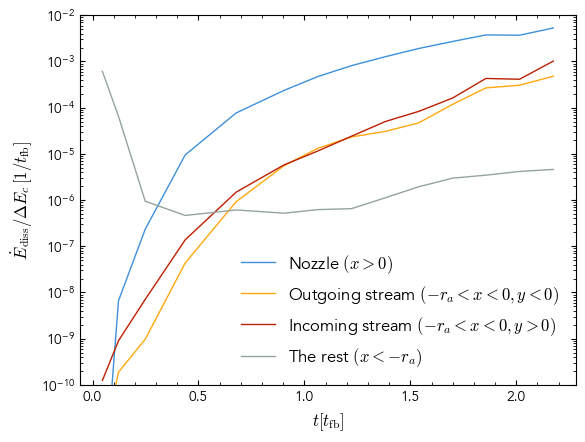

In [28]:
import matplotlib.pyplot as plt

reg = richio.units.registry
raw = np.loadtxt(OUTPUT_FILE, delimiter="\t").T
snapnums = raw[0]
t_in_tmins = raw[2]
Ediss_shock1_Deltas = u.unyt_array(raw[3], "1/code_time", registry=reg) * tmin
Ediss_shock2_Deltas = u.unyt_array(raw[4], "1/code_time", registry=reg) * tmin
Ediss_shock3_Deltas = u.unyt_array(raw[5], "1/code_time", registry=reg) * tmin
Ediss_shock4_Deltas = u.unyt_array(raw[6], "1/code_time", registry=reg) * tmin

plt.plot(t_in_tmins, Ediss_shock1_Deltas, label="Nozzle $(x>0)$")
plt.plot(t_in_tmins, Ediss_shock2_Deltas, label="Outgoing stream $(-r_a<x<0, y<0)$")
plt.plot(t_in_tmins, Ediss_shock3_Deltas, label="Incoming stream $(-r_a<x<0, y>0)$")
plt.plot(t_in_tmins, Ediss_shock4_Deltas, label="The rest $(x<-r_a)$")

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$\dot{E}_\mathrm{diss}/\Delta E_c\,[1/t_\mathrm{fb}]$")
plt.yscale("log")
plt.legend()
plt.ylim(1e-10, 1e-2)
plt.show()


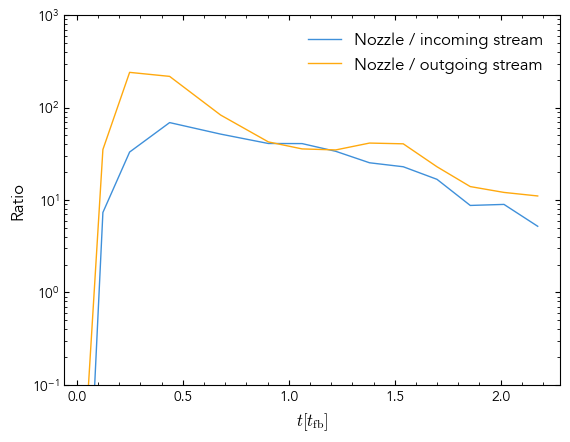

In [29]:
plt.plot(t_in_tmins, Ediss_shock1_Deltas/Ediss_shock3_Deltas, label="Nozzle / incoming stream")
plt.plot(t_in_tmins, Ediss_shock1_Deltas/Ediss_shock2_Deltas, label="Nozzle / outgoing stream")
plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"Ratio")
plt.yscale("log")
plt.legend()
plt.ylim(1e-1, 1e3)
plt.show()

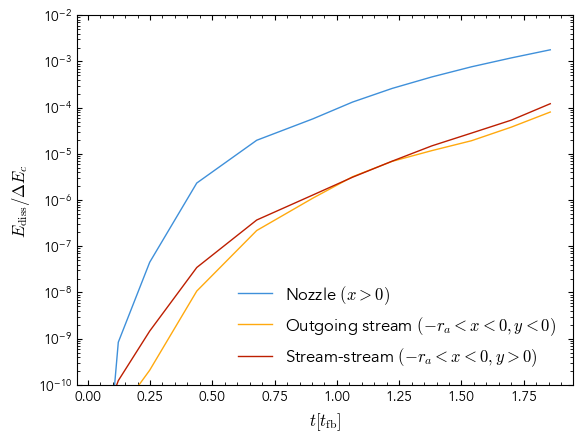

In [33]:
import matplotlib.pyplot as plt

reg = richio.units.registry
raw = np.loadtxt(OUTPUT_FILE, delimiter="\t").T
snapnums = raw[0]
ts = raw[1]
t_in_tmins = raw[2]

Ediss_shock1_Deltas = u.unyt_array(raw[3], "1/code_time", registry=reg)
Ediss_shock2_Deltas = u.unyt_array(raw[4], "1/code_time", registry=reg)
Ediss_shock3_Deltas = u.unyt_array(raw[5], "1/code_time", registry=reg)

Ediss_shock1_integrated = [np.sum(Ediss_shock1_Deltas[:i-1]*(ts[1:i]-ts[:i-1])) for i in range(2, len(ts))]
Ediss_shock2_integrated = [np.sum(Ediss_shock2_Deltas[:i-1]*(ts[1:i]-ts[:i-1])) for i in range(2, len(ts))]
Ediss_shock3_integrated = [np.sum(Ediss_shock3_Deltas[:i-1]*(ts[1:i]-ts[:i-1])) for i in range(2, len(ts))]

plt.plot(t_in_tmins[:-2], Ediss_shock1_integrated, label="Nozzle $(x>0)$")
plt.plot(t_in_tmins[:-2], Ediss_shock2_integrated, label="Outgoing stream $(-r_a<x<0, y<0)$")
plt.plot(t_in_tmins[:-2], Ediss_shock3_integrated, label="Stream-stream $(-r_a<x<0, y>0)$")
plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"${E}_\mathrm{diss}/\Delta E_c$")
plt.ylim(1e-10, 1e-2)
plt.yscale("log")
plt.legend()
plt.show()
